# 第4章 神经网络入门：分类与回归

分类和回归术语表：

- **样本**（sample）和**输入**（input）
- **预测**（prediction）和**输出**（output）
- **目标**（target）：真实值
- **预测误差**（prediction error）或**损失值**（loss value）
- **类别**（class）：1000 条数据中有猫和狗两个类别
- **标签**（label）：第 500 条数据的标签是狗
- **真实值**（ground-truth）或**标注**（annotation）
- **二分类**（binary classification）
- **多分类**（multiclass classification）
- **多标签分类**（multilabel classification）
- **标量回归**（scalar regression）：目标是一个连续标量值的任务。如：预测房价。
- **向量回归**（vector regression）：目标是一组连续值值的任务，如：识别图像边界。
- **小批量**（mini-batch）或**批量**（batch）

## 4.1 影评分类：二分类问题示例

### 4.1.1 IMDB 数据集

IMDB 数据集包含来自互联网电影数据库（IMDB）的 50000 条严重两极分化的评论。

代码清单 4-1 加载 IMDB 数据集

In [16]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

<__array_function__ internals>:180: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
/home/caoqiuyu/miniconda3/envs/tf-gpu/lib/python3.9/site-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/home/caoqiuyu/miniconda3/envs/tf-gpu/lib/python3.9/site-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with differ

> `num_words=10000` 的意思是仅保留训练数据中前 10000 个最常出现的单词。低频词将被舍弃。
>
> 标签有 `0` 和 `1` 两个类别，`0` 表示**负面**，`1` 表示**正面**.
> 
> 数据将评论的单词映射为单词索引

代码清单 4-2 将评论解码为文本

In [17]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]])

### 4.1.2 准备数据

神经网络不能处理长度各不相同的数据。需要对数据处理为大小相同的数据批量，将列表转换为张量的方法有：

- 填充列表，使其长度相同。

- 对列表进行**multi-hot 编码**，将其转换为由 0 和 1 组成的向量。例如，将序列 `[8 , 5]` 转换成一个 10 000 维的向量，只有索引 8 和 5 对应的元素是 1，其余元素都是 0。

代码清单 4-3 用 multi-hot 编码对证书列进行编码

In [18]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

### 4.1.3 构建模型

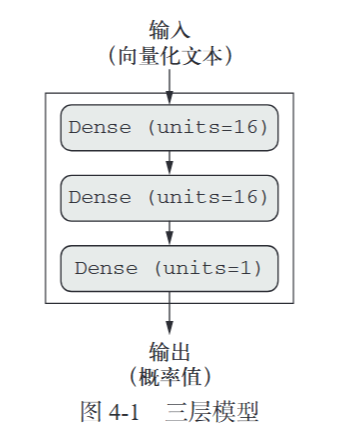

代码清单 4-4 模型定义

In [19]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

编译模型 4-5 编译模型

In [20]:
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

### 4.1.4 验证你的方法

代码清单 4-6 留出验证集

In [21]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

代码清单 4-7 训练模型

In [22]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 [==============================] - 2s 46ms/step - loss: 0.6218 - accuracy: 0.6847 - val_loss: 0.4413 - val_accuracy: 0.8678
Epoch 2/20
30/30 [==============================] - 1s 24ms/step - loss: 0.3830 - accuracy: 0.8928 - val_loss: 0.3363 - val_accuracy: 0.8813
Epoch 3/20
30/30 [==============================] - 1s 23ms/step - loss: 0.2727 - accuracy: 0.9165 - val_loss: 0.2895 - val_accuracy: 0.8913
Epoch 4/20
30/30 [==============================] - 1s 22ms/step - loss: 0.2056 - accuracy: 0.9376 - val_loss: 0.2727 - val_accuracy: 0.8941
Epoch 5/20
30/30 [==============================] - 1s 21ms/step - loss: 0.1560 - accuracy: 0.9541 - val_loss: 0.2758 - val_accuracy: 0.8889
Epoch 6/20
30/30 [==============================] - 1s 22ms/step - loss: 0.1312 - accuracy: 0.9607 - val_loss: 0.2806 - val_accuracy: 0.8877
Epoch 7/20
30/30 [==============================] - 1s 23ms/step - loss: 0.1060 - accuracy: 0.9713 - val_loss: 0.3042 - val_accuracy: 0.8828
Epoch 8/20
30

代码清单 4-8 绘制损失和验证损失

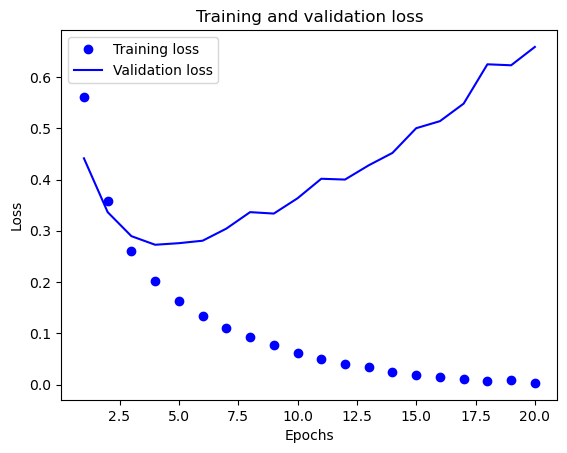

In [23]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

代码清单 4-9 绘制训练精度和验证精度

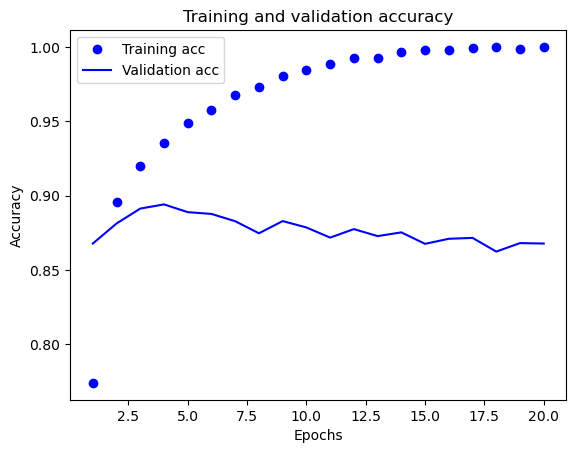

In [24]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

> 从上面两个图看到训练过程中，模型参数在训练数据上表现越来越好，但是在验证数据上表现地越来越不好，这就属于是**过拟合**（overfit）

代码清单 4-10 从头开始训练一个模型

In [25]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/4
49/49 [==============================] - 1s 19ms/step - loss: 0.5529 - accuracy: 0.7520
Epoch 2/4
49/49 [==============================] - 1s 15ms/step - loss: 0.2860 - accuracy: 0.9064
Epoch 3/4
49/49 [==============================] - 1s 15ms/step - loss: 0.2103 - accuracy: 0.9292
Epoch 4/4
782/782 [==============================] - 3s 3ms/step - loss: 0.2887 - accuracy: 0.8862
[0.28868618607521057, 0.8861600160598755]


### 4.1.5 利用训练好的模型对新数据进行预测

In [26]:
model.predict(x_test)

array([[0.17827865],
       [0.9983907 ],
       [0.8687415 ],
       ...,
       [0.12024003],
       [0.07908085],
       [0.5514226 ]], dtype=float32)

## 4.2 新闻分类：多分类问题示例

### 4.2.1 路透社数据集

本节将使用路透社数据集,它包含许多短新闻及其对应的主题,由路透社于 1986 年发布。  它是一个简单且广泛使用的文本分类数据集,其中包括 46 个主题。某些主题的样本相对较多,  但训练集中的每个主题都有至少 10 个样本

代码清单 4-11 加载路透社数据集

In [27]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

代码清单 4-12 将新闻解码为文本

In [28]:
word_index = reuters.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]])
# 索引减去 3，是因为 0、1、2 分别是为 "padding"（填充）、“start of sequence” (序列开始)、“unknown”（未知词）保留的索引。
print(decoded_newswire)

? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


### 4.2.2 准备数据

代码清单 4-13 编码输入数据

In [29]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

**one-hot 编码** 也叫**分类编码**（categorical encoding）。one-hot 和 multi hot 的区别是：


代码清单 4-14 编码标签

In [30]:
def to_one_hot(labels, dimension=46):
    results = np.zeros(len(labels), dimension)
    for i, label in enumerate(labels):
        results[i, label] = 1.
        return results
y_train = to_one_hot(train_labels)
t_test = to_one_hot(test_labels)

TypeError: Cannot interpret '46' as a data type

In [21]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

### 4.2.3 构建模型

代码清单 4-15 模型定义

In [24]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

代码清单 4-16 编译模型

In [25]:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

### 4.2.4 验证你的方法

从训练数据中留出 1000 个样本作为验证集

代码清单 4-17 留出验证集

In [26]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

代码清单 4-18 训练模型

In [ ]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 [==============================] - 1s 48ms/step - loss: 3.0254 - accuracy: 0.4232 - val_loss: 1.6682 - val_accuracy: 0.6320
Epoch 2/20
16/16 [==============================] - 0s 30ms/step - loss: 1.4267 - accuracy: 0.6934 - val_loss: 1.2782 - val_accuracy: 0.7110
Epoch 3/20
16/16 [==============================] - 0s 30ms/step - loss: 1.0428 - accuracy: 0.7735 - val_loss: 1.1009 - val_accuracy: 0.7640
Epoch 4/20
16/16 [==============================] - 0s 28ms/step - loss: 0.8047 - accuracy: 0.8275 - val_loss: 1.0000 - val_accuracy: 0.7880
Epoch 5/20
16/16 [==============================] - 0s 20ms/step - loss: 0.6222 - accuracy: 0.8689 - val_loss: 0.9460 - val_accuracy: 0.8010
Epoch 6/20
16/16 [==============================] - 0s 19ms/step - loss: 0.5116 - accuracy: 0.8936 - val_loss: 0.9156 - val_accuracy: 0.8120
Epoch 7/20
16/16 [==============================] - 0s 20ms/step - loss: 0.4059 - accuracy: 0.9172 - val_loss: 0.9060 - val_accuracy: 0.8100
Epoch 8/20
16

代码清单 4-19 绘制训练损失和验证损失

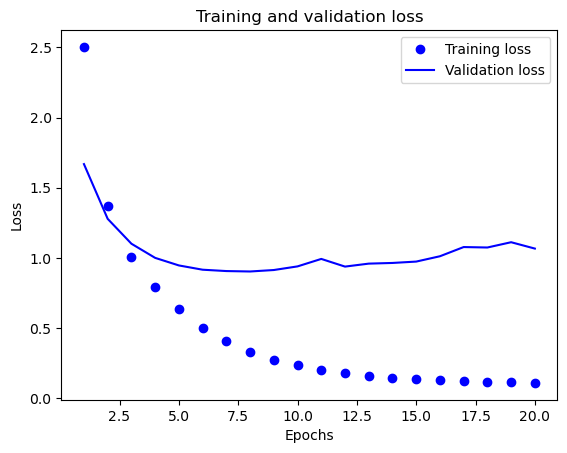

In [29]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


代码清单 4-20 绘制训练精度和验证精度

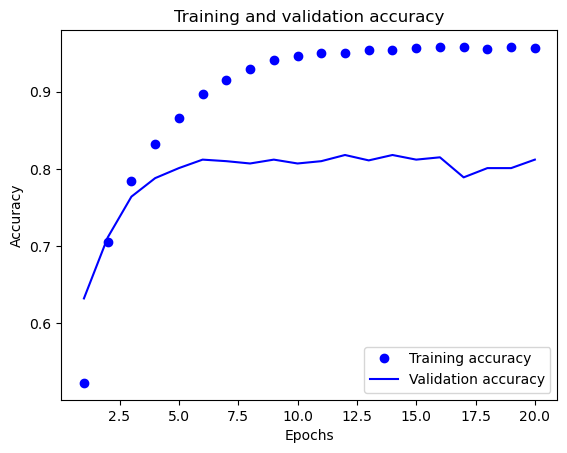

In [30]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

代码清单 4-21 从头开始训练一个模型

In [31]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512
)
results = model.evaluate(x_test, y_test)
print(results)

Epoch 1/9
18/18 [==============================] - 1s 33ms/step - loss: 3.1909 - accuracy: 0.3202
Epoch 2/9
18/18 [==============================] - 0s 21ms/step - loss: 1.5454 - accuracy: 0.6906
Epoch 3/9
18/18 [==============================] - 0s 16ms/step - loss: 1.1074 - accuracy: 0.7651
Epoch 4/9
18/18 [==============================] - 0s 18ms/step - loss: 0.8435 - accuracy: 0.8277
Epoch 5/9
18/18 [==============================] - 0s 17ms/step - loss: 0.6592 - accuracy: 0.8633
Epoch 6/9
18/18 [==============================] - 0s 18ms/step - loss: 0.5367 - accuracy: 0.8888
Epoch 7/9
18/18 [==============================] - 0s 17ms/step - loss: 0.4097 - accuracy: 0.9156
Epoch 8/9
18/18 [==============================] - 0s 20ms/step - loss: 0.3357 - accuracy: 0.9286
Epoch 9/9
71/71 [==============================] - 0s 5ms/step - loss: 0.9629 - accuracy: 0.7898
[0.9629319310188293, 0.7898486256599426]


### 4.2.5 对新数据进行预测

In [ ]:
predictions = model.predict(x_test)
print(predictions[0].shape)
print(np.sum(predictions[0]))
print(np.argmax(predictions[0]))

(46,)
0.9999999
3


### 4.2.6 处理标签和损失的另一种方法

In [36]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

### 4.2.7 拥有足够大的中间层的重要性

## 4.3 预测房价：标量回归问题示例

**回归**（regression）问题预测的是一个连续值，而不是离散标签。

> 不要将**回归**问题与**logistic 回归**算法混为一谈。logistic 回归不是回归算法，而是分类算法。

### 4.3.1 波士顿房价数据集

本节将尝试预测 20 世纪 70 年代中期波士顿郊区房价的中位数,已知当时郊区的一些数据点,  如犯罪率、地方房产税率等。本节用到的数据集与前两个例子有一个有趣的区别。

代码清单 4-23 加载波士顿房价数据集

In [37]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = (
    boston_housing.load_data())

57344/57026 [==============================] - 0s 2us/step


### 4.3.2 准备数据

将取值范围差异很大的数据输入到神经网络中是不合适的，这会使得学习变得困难。对于这类数据，普遍采的最佳处理方法是对每个特征进行**标准化**。即对于输入数据的每个特征（输入数据矩阵的每一列），减去特征平均值，再除以标准差，这样得到的特征平均值为 0，标准差为 1.

代码清单 4-24 数据标准化

In [38]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

### 4.3.3 构建模型


一般来说，训练数据越少，过拟合就会越严重，而较小的模型可以降低过拟合。

代码清单 4-35 模型定义

In [39]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

> 模型的最后一层只有一个单元且没有激活，它是一个线性层。这是标量回归的典型设置。如果最后一层添加 sigmoid 激活函数，那么模型只能学会预测 0 到 1 的值。

**均方误差**（mean suqared error，MSE）损失函数，预测值与目标值之差的平方。

监控指标**平均绝对误差**（mean absolute error，MAE），是预测值与目标值之差的绝对值。

### 4.3.4 利用 $K$ 折交叉验证来验证你的方法

由于数据点很小，验证集会非常小（比如大约 100 个样本），因此验证分数可能会有很大波动，这取决于我们所选择的验证集和训练集。也就是说，验证分数对于验证集的划分方式可能有很大的**方差**，这样我们就无法对模型进行可靠的评估。

这种情况下，最佳做法就是使用 $K$ 折交叉验证。

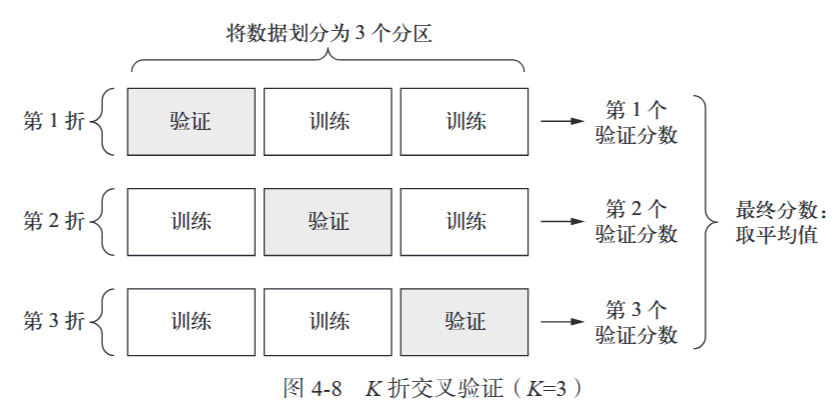

这种方法将可用数据划分为 $K$ 个分区( $K$ 通常取 4 或 5),实例化 $K$ 个相同的模型,然后将每个模型在 $K−1$ 个分区上训练,并在剩下的一个分区上进行评估。模型的验证分数等于这 $K$ 个验证分数的平均值。

代码清单 4-26 $K$ 折交叉验证

In [ ]:
k = 4
num_cal_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_cal_samples: (i + 1) * num_cal_samples]
    val_targets = train_targets[i * num_cal_samples: (i + 1) * num_cal_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_cal_samples],
         train_data[(i + 1) * num_cal_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_cal_samples],
         train_targets[(i + 1) * num_cal_samples:]],
        axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,
                  epochs=num_epochs, batch_size=16, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)
    

Processing fold #0


2025-02-13 13:55:51.387420: W tensorflow/core/framework/op_kernel.cc:1763] OP_REQUIRES failed at cwise_op_gpu_base.cc:89 : Internal: Failed to load in-memory CUBIN: CUDA_ERROR_NO_BINARY_FOR_GPU: no kernel image is available for execution on the device


InternalError:  Failed to load in-memory CUBIN: CUDA_ERROR_NO_BINARY_FOR_GPU: no kernel image is available for execution on the device
	 [[node Abs (defined at tmp/ipykernel_15728/2434292621.py:18) ]] [Op:__inference_train_function_11965]

Function call stack:
train_function
